In [2]:
%cd ..

c:\Users\stlp\GPSImpute


In [3]:
import pandas as pd
import numpy as np
import mobileDataToolkit.preprocessing_v2 as preprocessing

ModuleNotFoundError: No module named 'torch'

In [ ]:
# Load sampled data
df = pd.read_csv('C:\\Users\\stlp\\OneDrive - UW\\GPR\\Data\\seattle_2000_all_obs_preprocessed_sampled.csv')

In [ ]:
df.head()

,UID,orig_lat,orig_long,orig_unc,datetime,unix_min,DoW,Year,Month,Day,Week,Hour,WoM,SaM,Holiday
0,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.555557,-122.050186,65.0,2019-12-31 06:31:49,0,1,2019,12,31,1,6,5,23509,0
1,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.551100,-122.052466,65.0,2019-12-31 06:53:18,21,1,2019,12,31,1,6,5,24798,0
2,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.551393,-122.053351,65.0,2019-12-31 07:08:22,36,1,2019,12,31,1,7,5,25702,0
3,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.551065,-122.052334,65.0,2019-12-31 07:18:00,46,1,2019,12,31,1,7,5,26280,0
4,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.555557,-122.050186,65.0,2019-12-31 07:19:26,47,1,2019,12,31,1,7,5,26366,0


In [ ]:
mod = preprocessing.dp_MultiTrip(df)
mod.chooseUser(df.UID.unique()[0])

In [ ]:
# Add datetime column without time
mod.data['date'] = pd.to_datetime(mod.data['datetime']).dt.date

# Check which days in April have the most observations
mod.data[pd.to_datetime(mod.data['datetime']).dt.month == 4].groupby('date').count().sort_values('datetime', ascending=False)['UID'].head()

C:\Users\ekino\AppData\Local\Temp\ipykernel_22976\4107106159.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mod.data['date'] = pd.to_datetime(mod.data['datetime']).dt.date


date
2020-04-30    297
2020-04-22    284
2020-04-03    247
2020-04-08    229
2020-04-29    213
Name: UID, dtype: int64

In [ ]:
# Choose the day with the most observations as our test day
test_day = mod.data[pd.to_datetime(mod.data['datetime']).dt.month == 4].groupby('date').count().sort_values('datetime', ascending=False).index[0]

# Check the hourly sampling distribution for our test day
mod.data[mod.data['date'] == test_day].groupby(pd.to_datetime(mod.data['datetime']).dt.hour).count()['UID'].sort_values(ascending=False)

datetime
12    88
2     59
3     32
0     32
13    20
1     18
5      5
4      4
9      4
17     3
22     3
7      3
20     3
18     3
16     3
21     2
19     2
23     2
15     2
11     2
10     2
8      2
6      2
14     1
Name: UID, dtype: int64

In [ ]:
mod.data[mod.data['date'] == test_day].groupby(pd.to_datetime(mod.data['datetime']).dt.hour).count()['UID'].sort_values(ascending=False).index[:2]

Int64Index([12, 2], dtype='int64', name='datetime')

In [ ]:
# Choose three hours with the most observations as our test hours
test_hours = mod.data[mod.data['date'] == test_day].groupby(pd.to_datetime(mod.data['datetime']).dt.hour).count()['UID'].sort_values(ascending=False).index[:3]

# Segment dataset accordingly
mod.subsetByTime(starttime='{} {}'.format(str(test_day), str(test_hours[0]) + ':00:00'), endtime='{} {}'.format(str(test_day), str(test_hours[-1]) + ':00:00'))

,index,UID,orig_lat,orig_long,orig_unc,datetime,unix_min,DoW,Year,Month,Day,Week,Hour,WoM,SaM,Holiday,date
0,34417,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.555557,-122.050186,65.0,2020-04-30 12:09:51,174518,3,2020,4,30,18,12,5,43791,0,2020-04-30
1,34418,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.555557,-122.050186,5.0,2020-04-30 12:10:10,174518,3,2020,4,30,18,12,5,43810,0,2020-04-30
2,34419,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.550912,-122.054413,10.0,2020-04-30 12:11:09,174519,3,2020,4,30,18,12,5,43869,0,2020-04-30
3,34420,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.551793,-122.058559,10.0,2020-04-30 12:11:54,174520,3,2020,4,30,18,12,5,43914,0,2020-04-30
4,34421,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.550927,-122.066730,10.0,2020-04-30 12:12:40,174520,3,2020,4,30,18,12,5,43960,0,2020-04-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,34544,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.446320,-122.204887,65.0,2020-04-30 22:15:42,175123,3,2020,4,30,18,22,5,80142,0,2020-04-30
128,34545,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.446320,-122.204887,65.0,2020-04-30 22:36:44,175144,3,2020,4,30,18,22,5,81404,0,2020-04-30
129,34546,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.446320,-122.204887,65.0,2020-04-30 22:55:53,175164,3,2020,4,30,18,22,5,82553,0,2020-04-30
130,34547,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.446320,-122.204887,65.0,2020-04-30 23:16:24,175184,3,2020,4,30,18,23,5,83784,0,2020-04-30


In [ ]:
import torch
import gpytorch
from gpytorch.kernels import RQKernel as RQ, RBFKernel as SE, \
PeriodicKernel as PER, ScaleKernel, LinearKernel as LIN, MaternKernel as MAT, \
SpectralMixtureKernel as SMK, PiecewisePolynomialKernel as PPK, CylindricalKernel as CYL
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error
from gpytorch.constraints import Interval
import time

import mobileDataToolkit.methods as methods

C:\Users\ekino\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\linear_operator\utils\deprecation.py:13: UserWarning: Failed to initialize NumPy: module compiled against API version 0x10 but this version of numpy is 0xf (Triggered internally at ..\torch\csrc\utils\tensor_numpy.cpp:77.)
  bool_compat = (torch.ones(1) > 0).dtype


In [ ]:
mod.data.columns

Index(['index', 'UID', 'orig_lat', 'orig_long', 'orig_unc', 'datetime',
       'unix_min', 'DoW', 'Year', 'Month', 'Day', 'Week', 'Hour', 'WoM', 'SaM',
       'Holiday', 'date'],
      dtype='object')

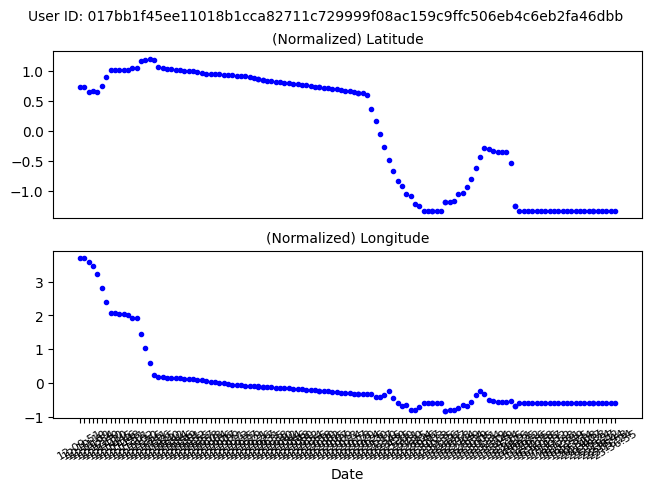

In [ ]:
mod.add_NormCoords()

methods.mobVisualize(mod.data)

## Induce gaps

In [ ]:
import mobileDataToolkit.analysis as analysis

# Define target temporal occupancy
target_temp_ocp = 0.1

# Simulate gaps in the user's data to match the target level
gapped_user_data = analysis.simulate_gaps(mod.data, target_temp_ocp)

# Check the temporal occupancy of the new gapped user data
temp_ocp = analysis.tempOcp(gapped_user_data, bin_len=5)
print(f"Temporal occupancy of user {user_id} is now {temp_ocp}.")

ModuleNotFoundError: No module named 'mobileDataToolkit'

In [ ]:
def tempOcp(data, bin_len = 5):
    """
    Calculates the temporal occupancy of a given mobile data sequence.

    Parameters
    ----------
    data: pd.DataFrame
        Trajectory data that needs to be processed
    
    bin_len : INT, optional
        Number of minutes in a time interval (bin). The default is 5.

    Returns
    -------
    temp_ocp : FLOAT
    Temporal occupancy metric.

    """
    bins = np.arange(min(data['unix_min']), max(data['unix_min'])+1, bin_len )
    Nb = len(bins)
    obs = list()
    for i, j in enumerate(bins):
        if i == Nb:
            break
        hi = list()
        for k in range(int(bins[i]), int(bins[i+1])):
            condition = [k in data['unix_min'].values]
            hi.append(any(condition))
        if any(hi):
            obs.append(1)
        if i == (Nb-2):
            break
    obs.append(1)
    temp_ocp = float(len(obs) / len(bins))
    return temp_ocp

def simulate_gaps(data, target_temp_ocp, user_id=None, bin_len=5):
    if user_id is not None:
        user_data = data[data['user_id'] == user_id]
    else:
        user_data = data
    current_temp_ocp = tempOcp(user_data, bin_len)
    if current_temp_ocp <= target_temp_ocp:
        print(f"User {user_id} already has temporal occupancy of {current_temp_ocp}.")
        return None
    else:
        target_bins = int(len(user_data) * target_temp_ocp)
        current_bins = len(np.unique(user_data['unix_min'])) - 1
        if target_bins >= current_bins:
            print(f"Cannot decrease temporal occupancy for user {user_id} to {target_temp_ocp}.")
            return None
        else:
            gap_size = int((current_bins - target_bins) / (target_bins + 1))
            gap_starts = np.arange(gap_size, current_bins, gap_size+1)
            gap_starts = gap_starts[:-1] # exclude last element to avoid index out of bounds
            print(gap_starts)
            gap_ends = gap_starts + int(gap_size/2)
            for start, end in zip(gap_starts, gap_ends):
                start_time = user_data.iloc[start]['unix_min']
                #print(start_time)
                if (start_time == user_data.iloc[-1]['unix_min']) or (start_time == user_data.iloc[-2]['unix_min']):
                    break
                end_time = user_data.iloc[end]['unix_min']
                user_data = user_data[user_data['unix_min'] < start_time]\
                            .append(user_data[user_data['unix_min'] > end_time])
                
            return user_data.reset_index(drop=True), user_data.index

# Define target temporal occupancy
target_temp_ocp = 0.3

# Simulate gaps in the user's data to match the target level
gapped_user_data, train_index = simulate_gaps(mod.data, target_temp_ocp, bin_len = 15)

# Check the temporal occupancy of the new gapped user data
temp_ocp = tempOcp(gapped_user_data, bin_len=15)
temp_ocp

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53]


0.3695652173913043

In [ ]:
train = mod.data.iloc[train_index].copy()
test = mod.data.drop(train_index).copy()

print(len(train))
len(test)

31


101

## Stack the local training set with the longitudinal training data
* Implement lines from other files